In [2]:
import pandas as pd,numpy as np
import matplotlib.pyplot as plt,seaborn as sns
import kagglehub

In [3]:
path = kagglehub.dataset_download("yasserh/loan-default-dataset")

df = pd.read_csv(path + "/Loan_Default.csv", encoding="latin1")

df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
df = df.drop(['year','ID'],axis=1)


In [6]:
CatCols = df.select_dtypes(object).columns

In [7]:
NumCols = df.select_dtypes(exclude=object).columns

In [7]:
df[NumCols]

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
0,116500,NaN,NaN,NaN,360.0,118000.0,1740.0,758,98.728814,1,45.0
1,206500,NaN,NaN,NaN,360.0,NaN,4980.0,552,NaN,1,NaN
2,406500,4.560,0.2000,595.00,360.0,508000.0,9480.0,834,80.019685,0,46.0
3,456500,4.250,0.6810,NaN,360.0,658000.0,11880.0,587,69.376900,0,42.0
4,696500,4.000,0.3042,0.00,360.0,758000.0,10440.0,602,91.886544,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...
148665,436500,3.125,0.2571,9960.00,180.0,608000.0,7860.0,659,71.792763,0,48.0
148666,586500,5.190,0.8544,0.00,360.0,788000.0,7140.0,569,74.428934,0,15.0
148667,446500,3.125,0.0816,1226.64,180.0,728000.0,6900.0,702,61.332418,0,49.0
148668,196500,3.500,0.5824,4323.33,180.0,278000.0,7140.0,737,70.683453,0,29.0


In [8]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [9]:
df.shape

(148670, 32)

In [10]:
df.isnull().sum()

loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
LTV                          15098
Region              

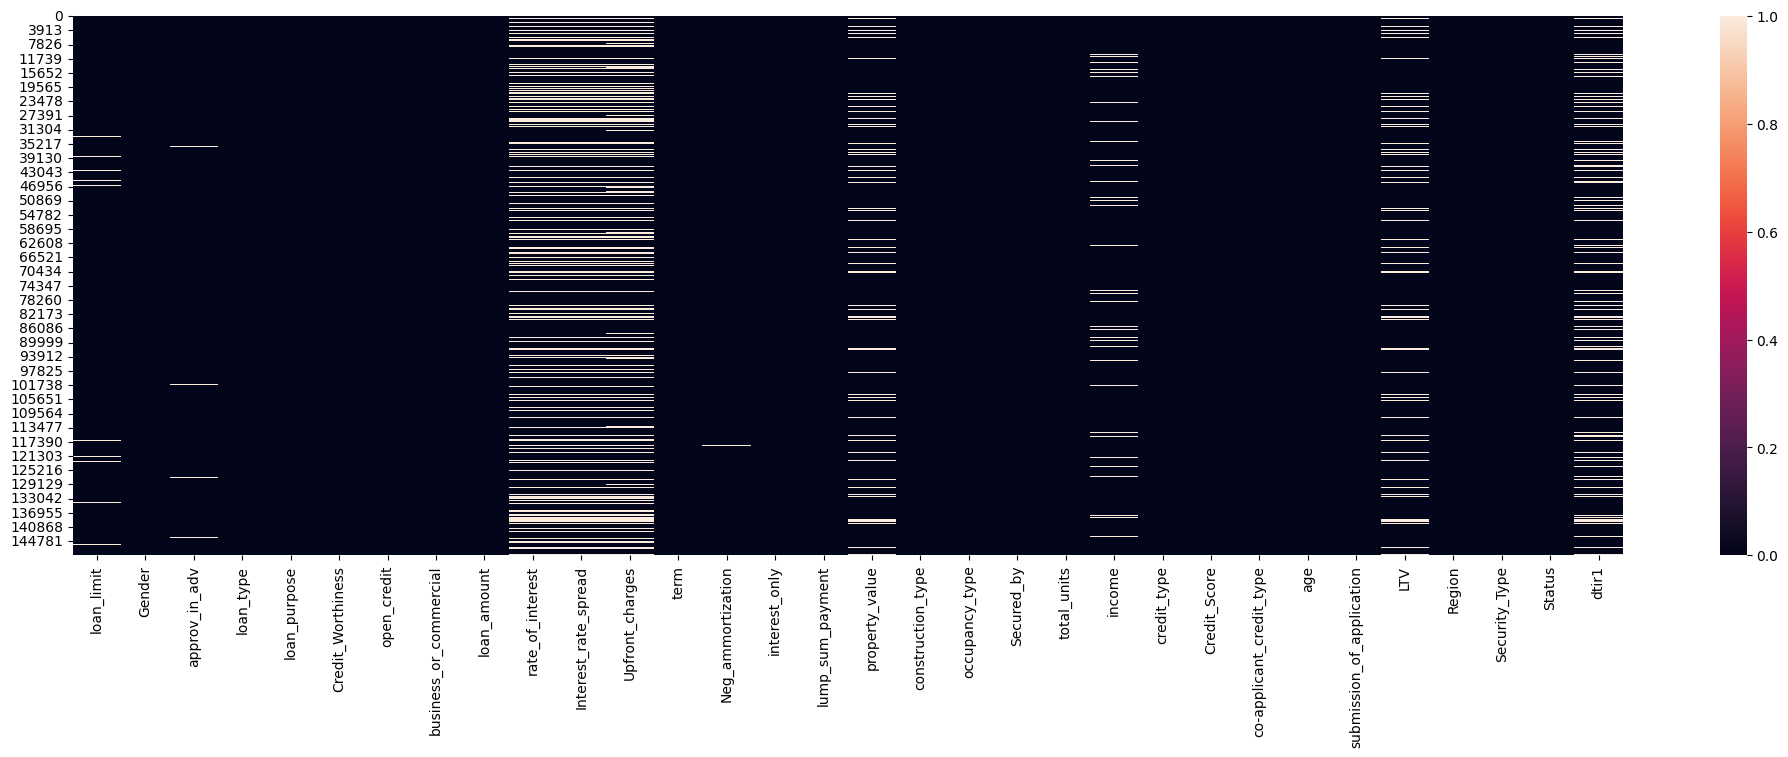

In [11]:
plt.figure(figsize=(25,7))
sns.heatmap(df.isnull())
plt.show()

## Categorical Columns details

In [12]:
for col in CatCols:
    print("*"*28)
    print(df[col].value_counts())

****************************
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64
****************************
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64
****************************
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64
****************************
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64
****************************
loan_purpose
p3    55934
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64
****************************
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64
****************************
open_credit
nopc    148114
opc        556
Name: count, dtype: int64
****************************
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64
****************************
Neg_ammortization
not_neg    133420
neg_amm     15129
Name: count, dtyp

In [13]:
sns.set_theme(style="whitegrid")

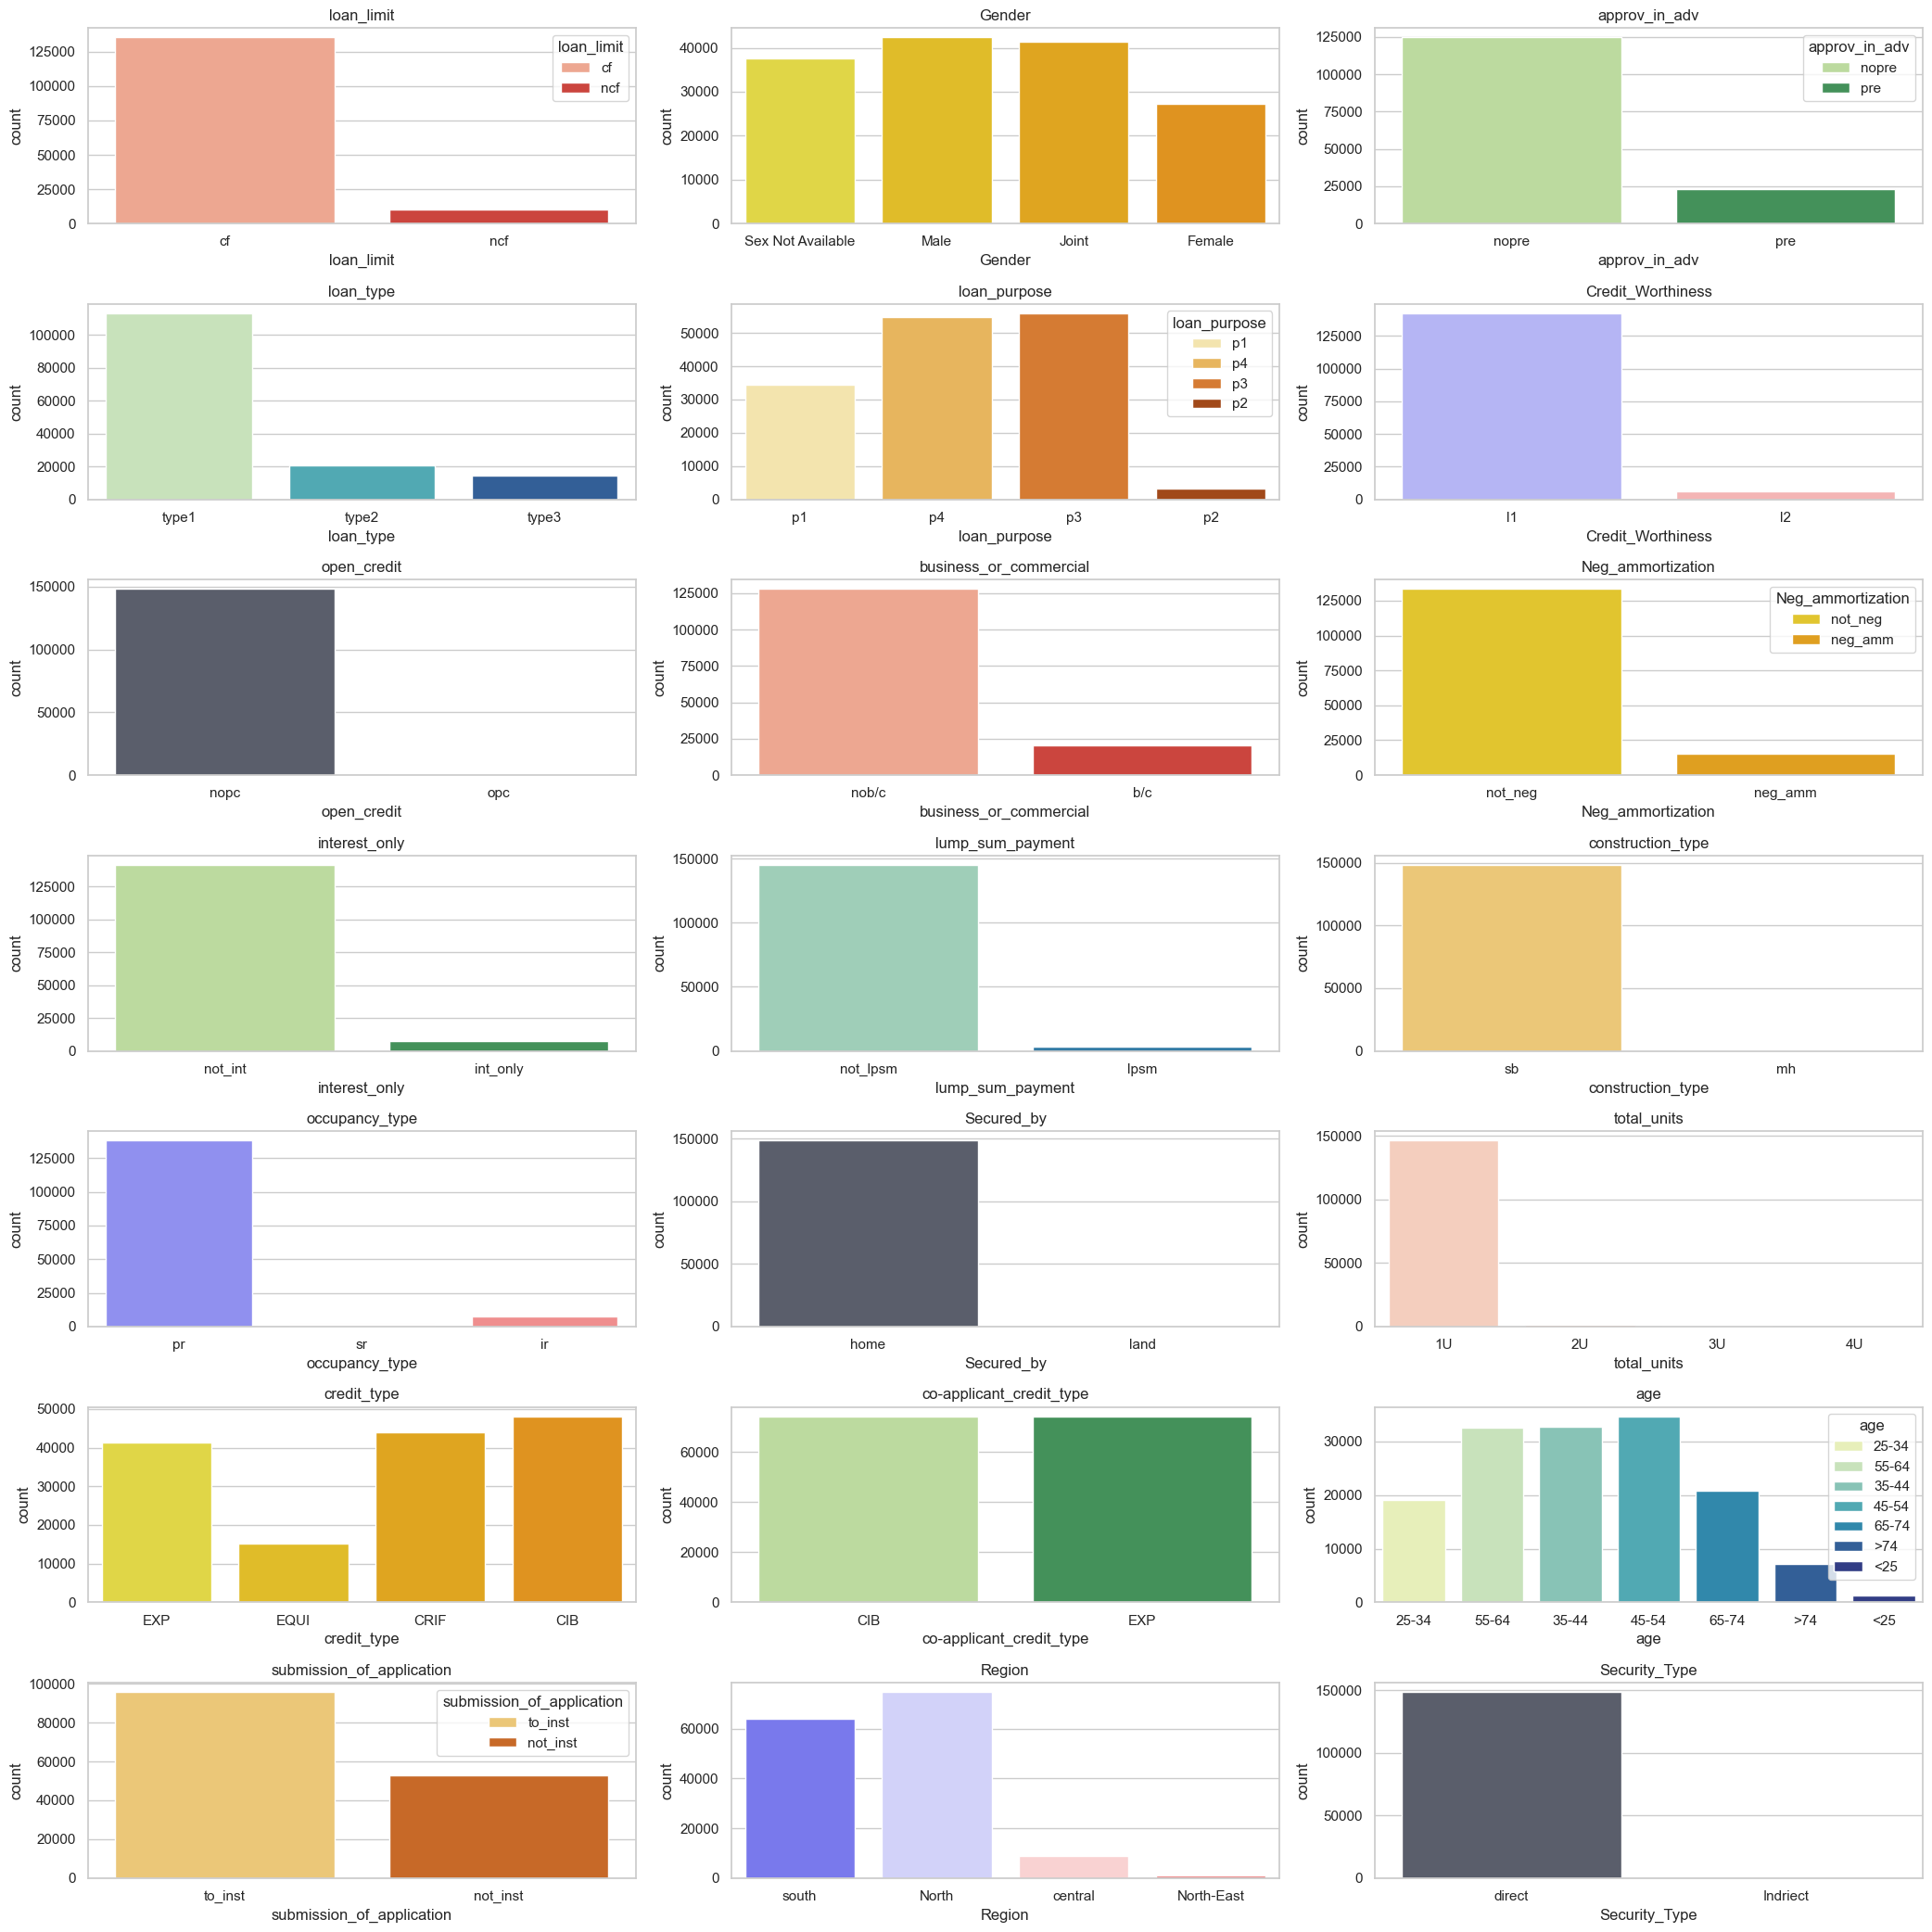

In [14]:
fig,axes = plt.subplots(7,3,figsize=(21,21))
ax = axes.flatten()
p = ['Reds','Wistia','YlGn','YlGnBu','YlOrBr','bwr','cividis']
for i,col in enumerate(CatCols):
    sns.countplot(df,x=col,hue=col,ax=ax[i],palette=p[i%7]).set_title(col)

plt.tight_layout()
plt.show()

In [15]:
df[df['Security_Type']=='Indriect']['Status']

7973      1
32312     1
34412     1
35368     1
36155     1
41151     1
44592     1
46022     1
47828     1
56153     1
59732     1
60122     1
62581     1
68927     1
82520     1
85185     1
90473     1
91255     1
104761    1
105639    1
106363    1
109160    1
109448    1
109934    1
120254    1
122468    1
123610    1
124614    1
125783    1
128515    1
140486    1
146525    1
148023    1
Name: Status, dtype: int64

### hue: Status

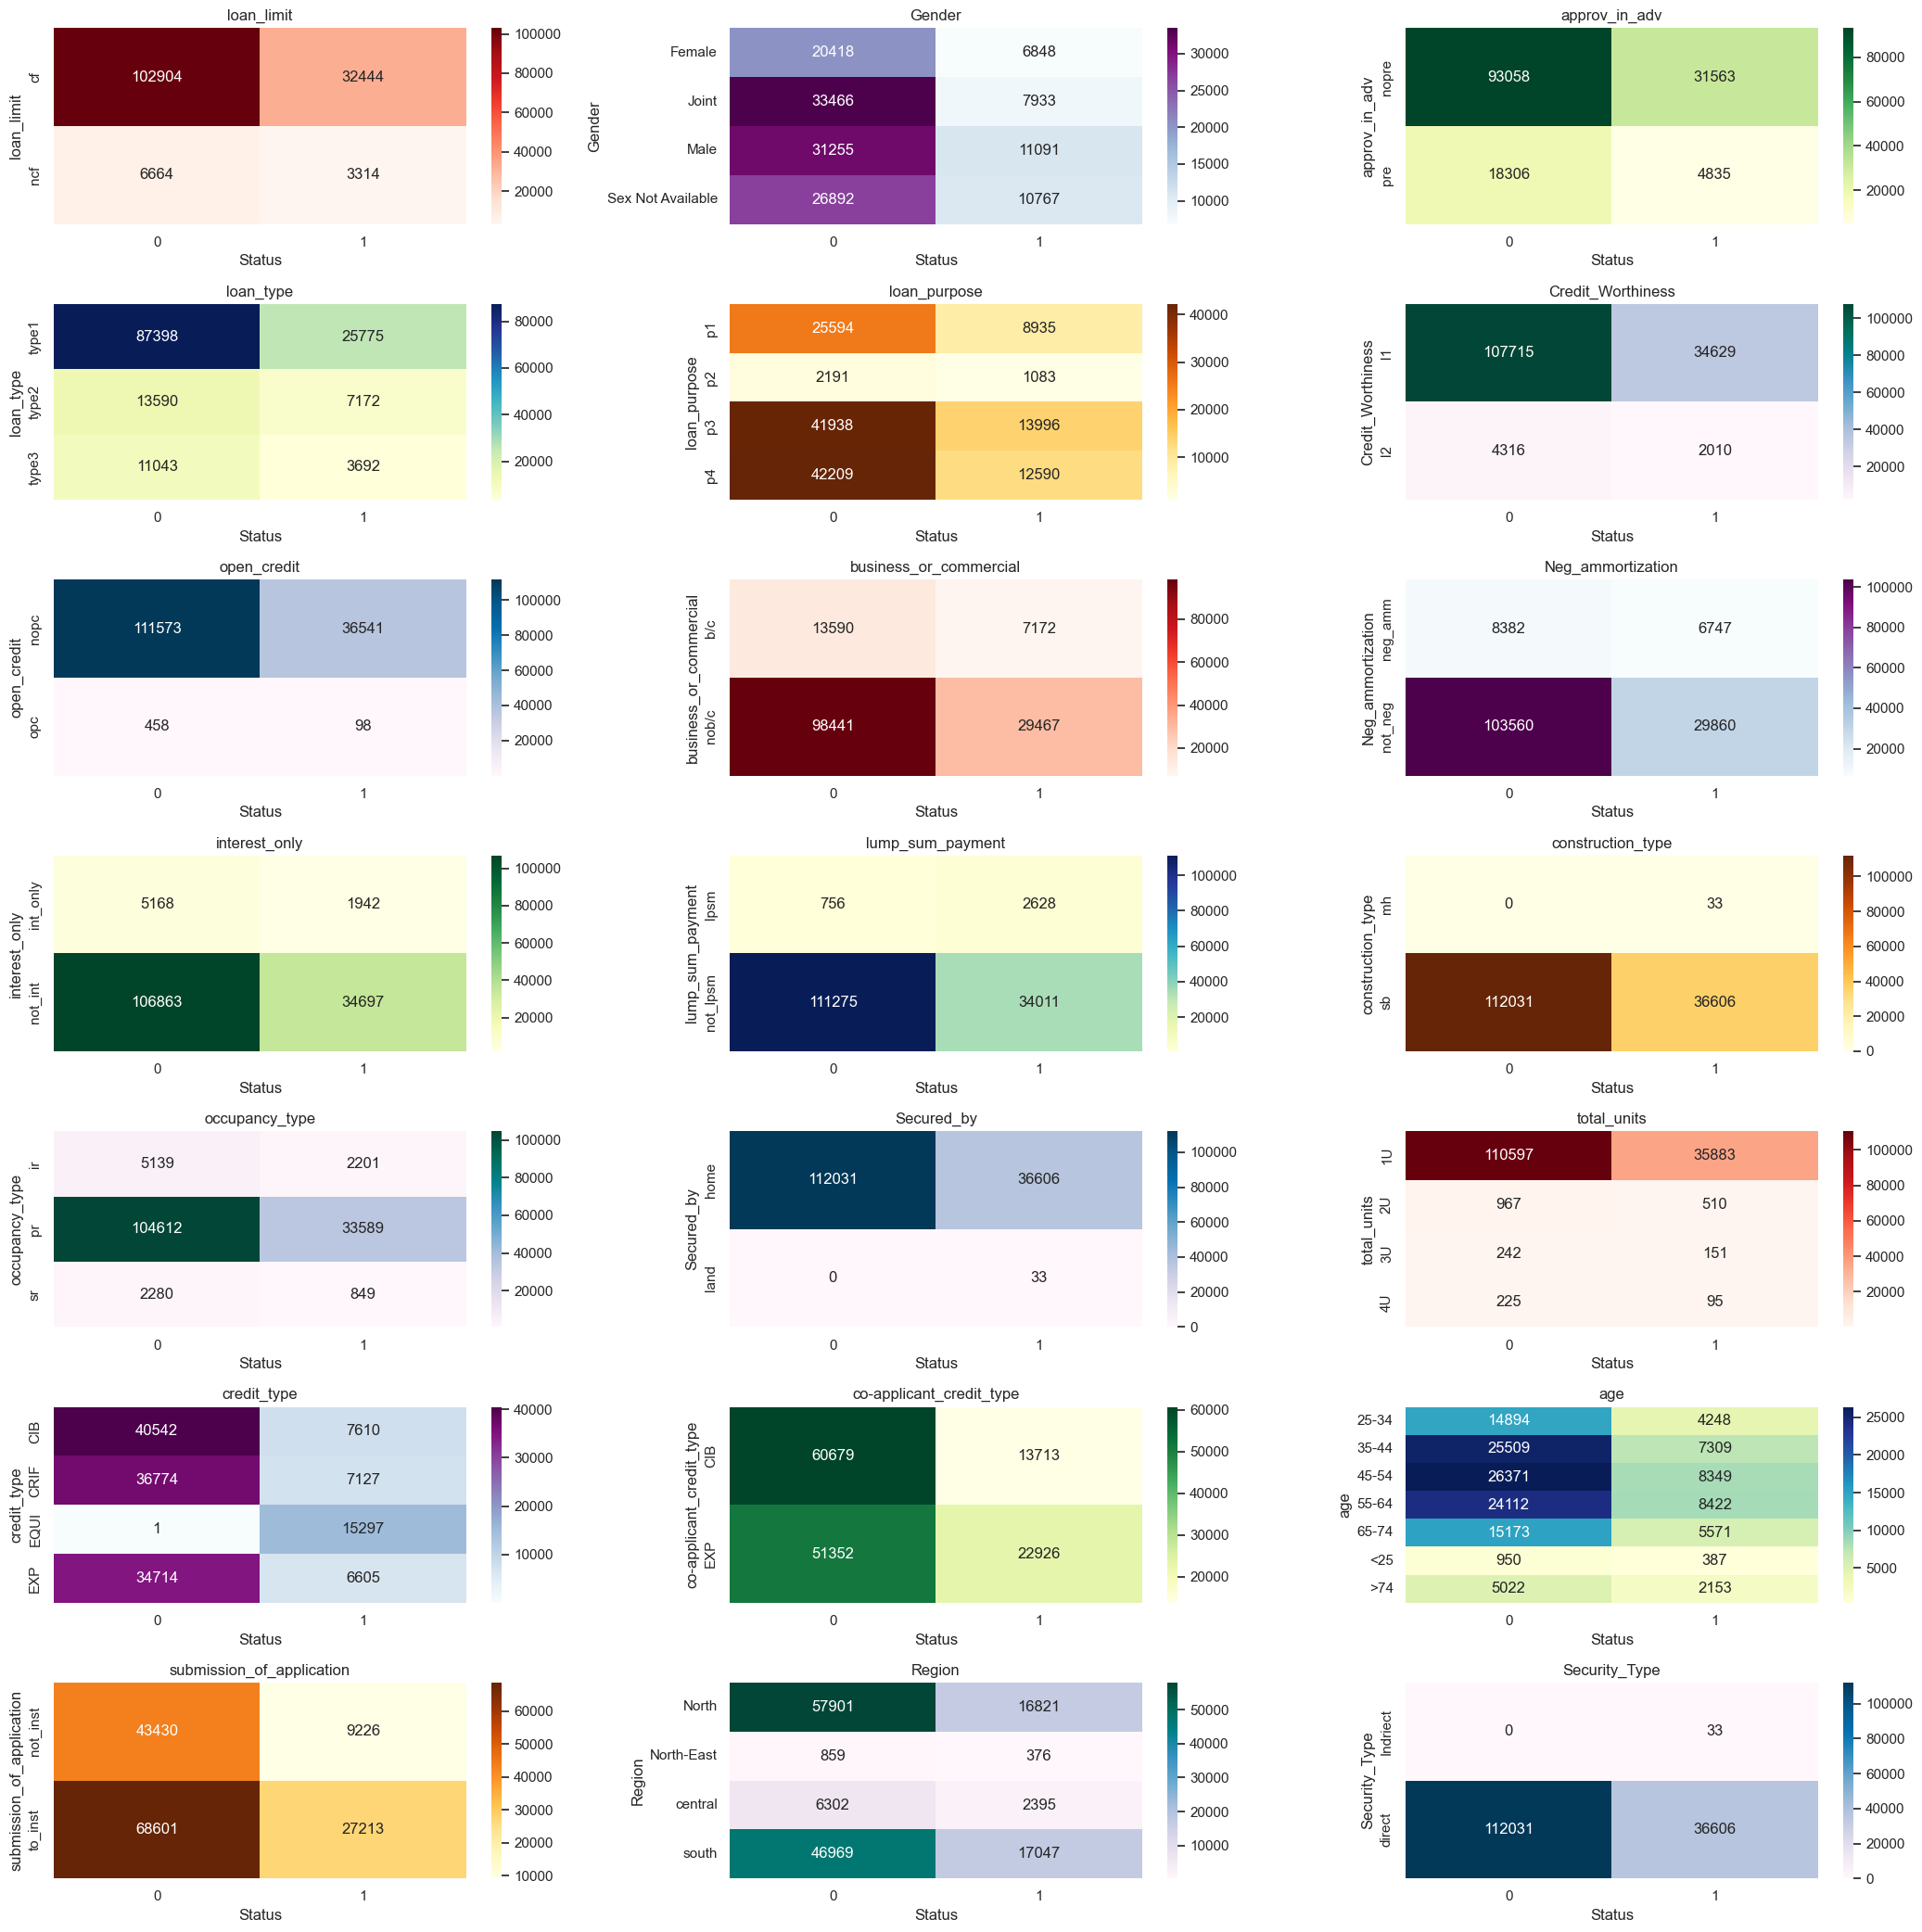

In [16]:
fig,axes = plt.subplots(7,3,figsize=(21,21))
ax = axes.flatten()
colors = ['Reds','BuPu','YlGn','YlGnBu','YlOrBr','PuBuGn','PuBu']
for i,col in enumerate(CatCols):
    sns.heatmap(pd.crosstab(columns=df['Status'],index=df[col]),annot=True,fmt="d",ax=ax[i],cmap=colors[i%7]).set_title(col)

plt.tight_layout()
plt.show()

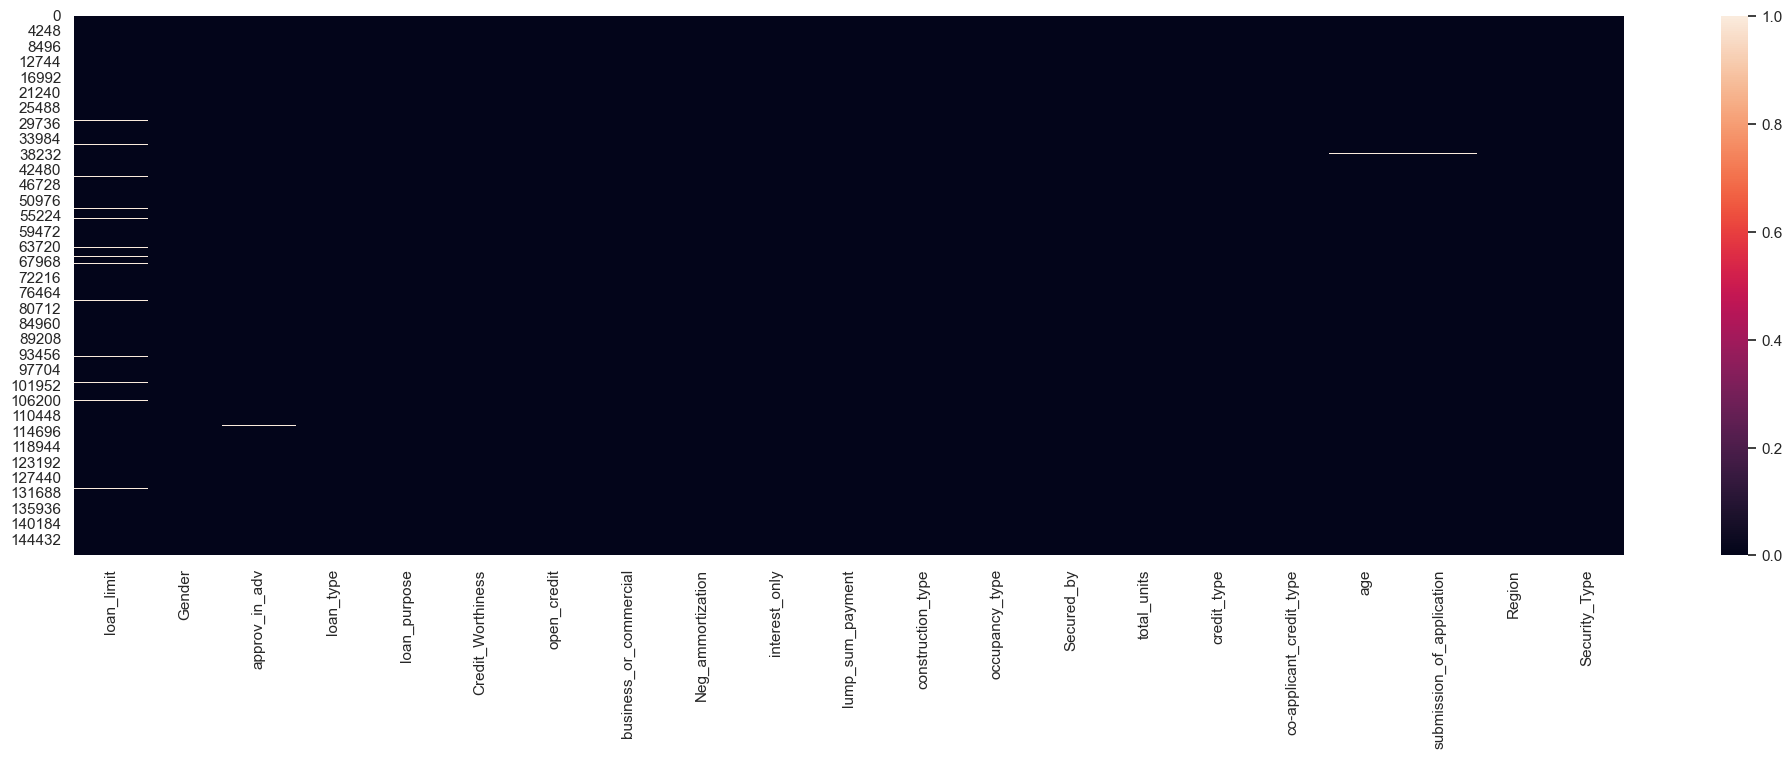

In [17]:
plt.figure(figsize=(25,7))
sns.heatmap(df[CatCols].isnull())
plt.show()

In [18]:
df.dropna()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.560,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.000,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,3.990,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,4.500,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
8,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,4.875,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.125,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.190,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.125,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.500,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


In [19]:
df[CatCols].isnull().sum()

loan_limit                   3344
Gender                          0
approv_in_adv                 908
loan_type                       0
loan_purpose                  134
Credit_Worthiness               0
open_credit                     0
business_or_commercial          0
Neg_ammortization             121
interest_only                   0
lump_sum_payment                0
construction_type               0
occupancy_type                  0
Secured_by                      0
total_units                     0
credit_type                     0
co-applicant_credit_type        0
age                           200
submission_of_application     200
Region                          0
Security_Type                   0
dtype: int64

## Numeric Columns details

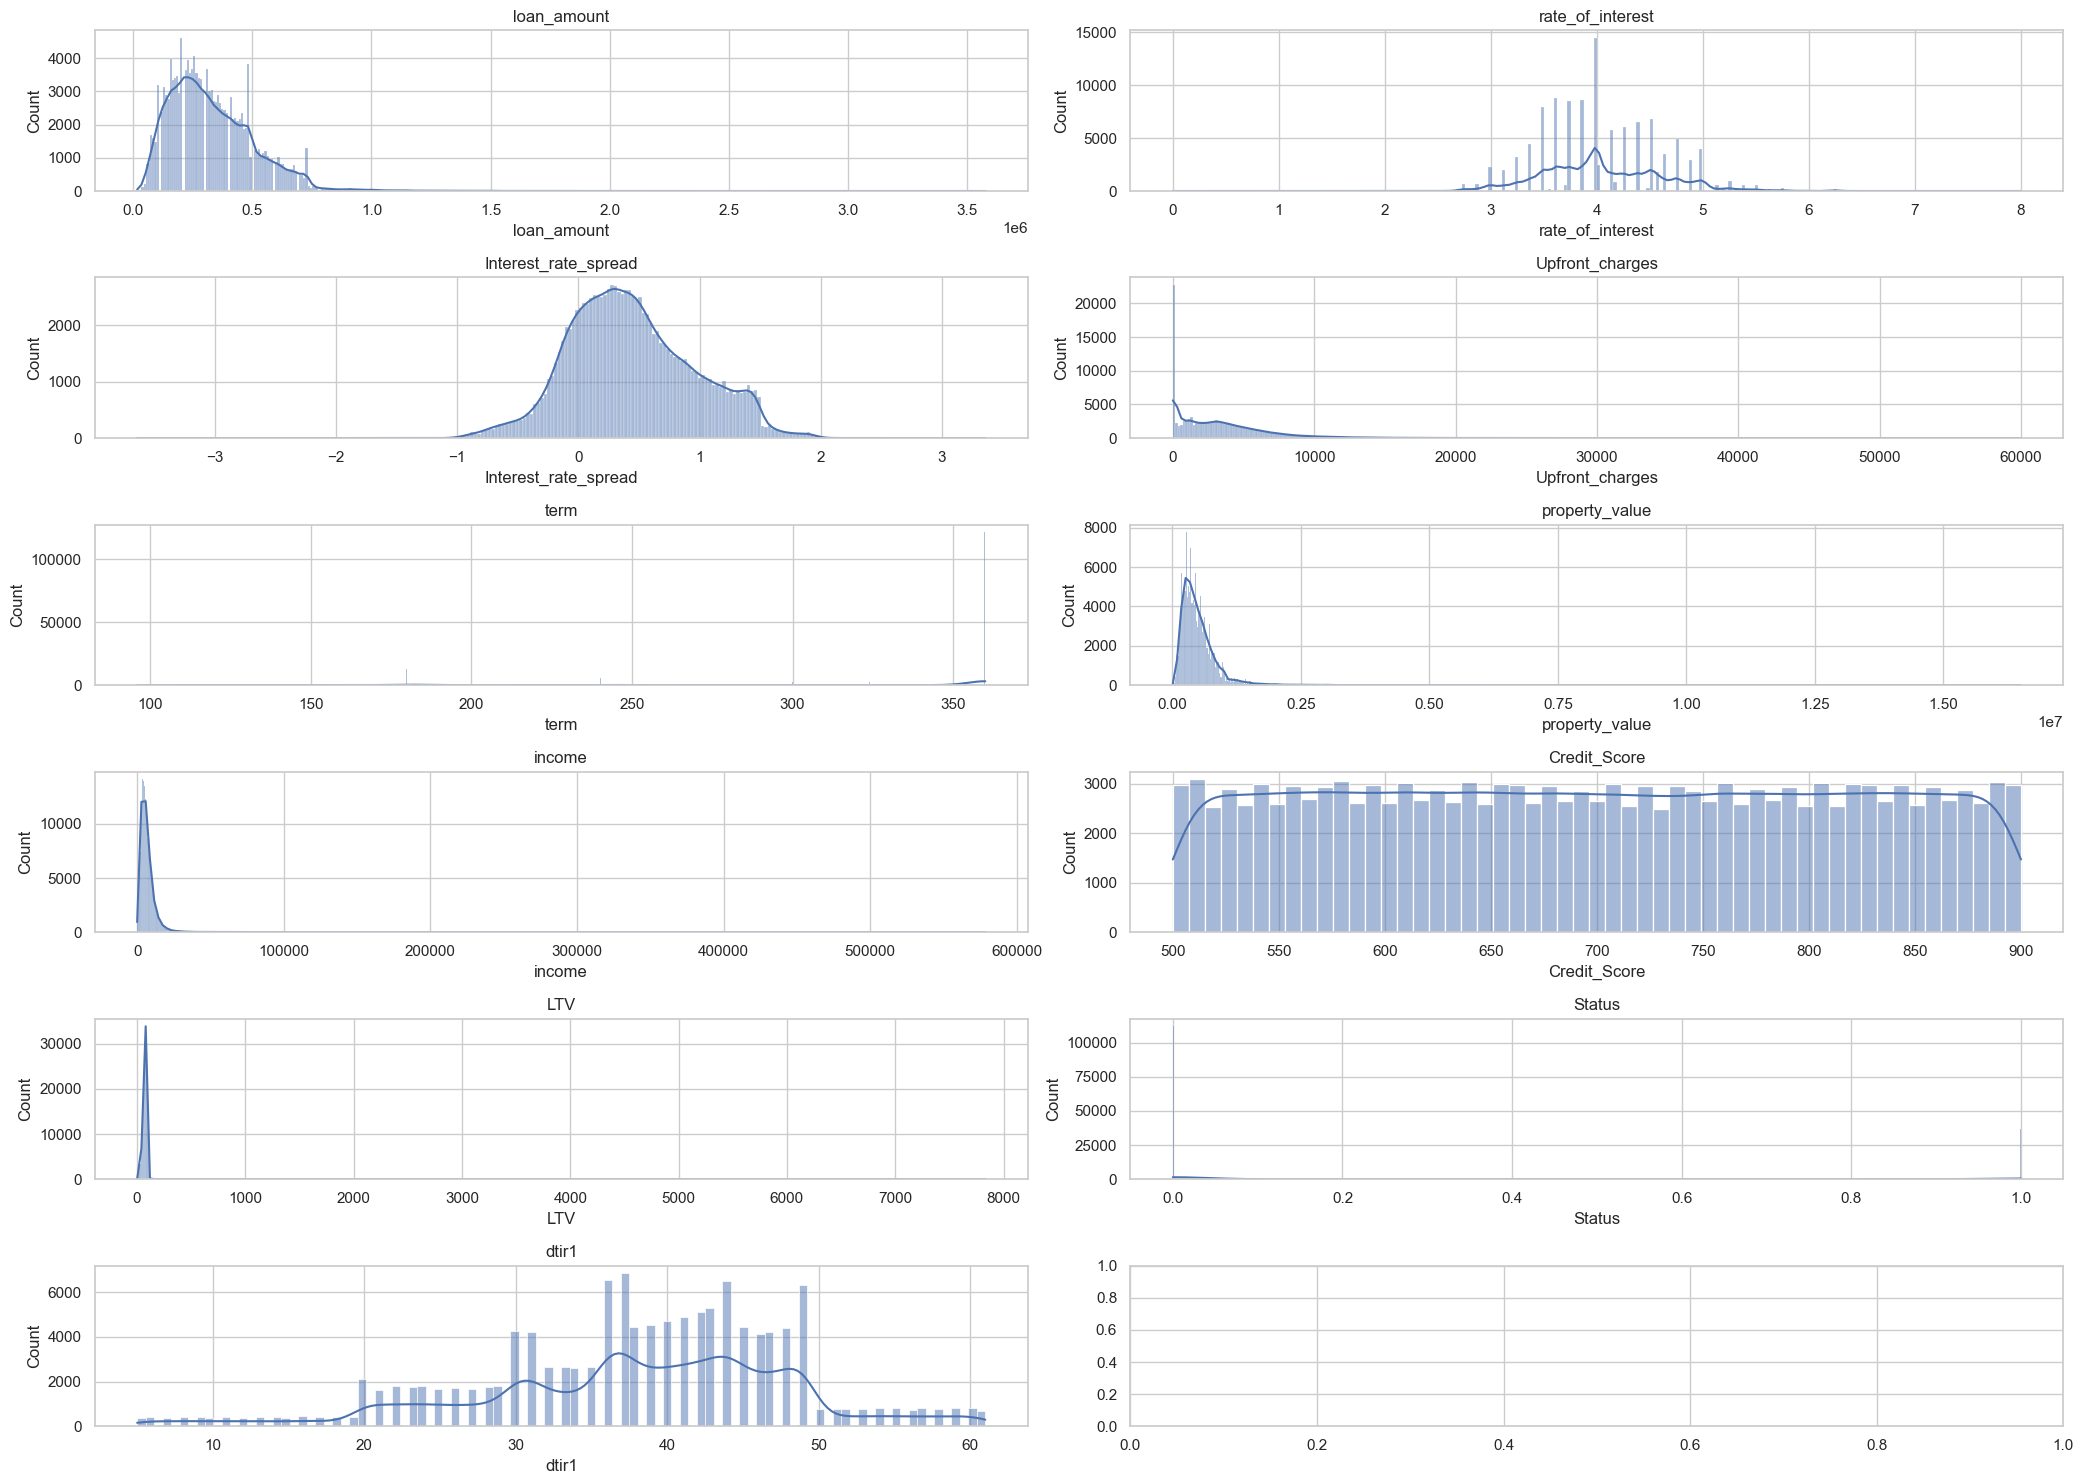

In [21]:
fig2,axes2 = plt.subplots(6,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(NumCols):
    sns.histplot(df,kde=True,x=col,ax=ax2[i]).set_title(col)

plt.tight_layout()
plt.show()

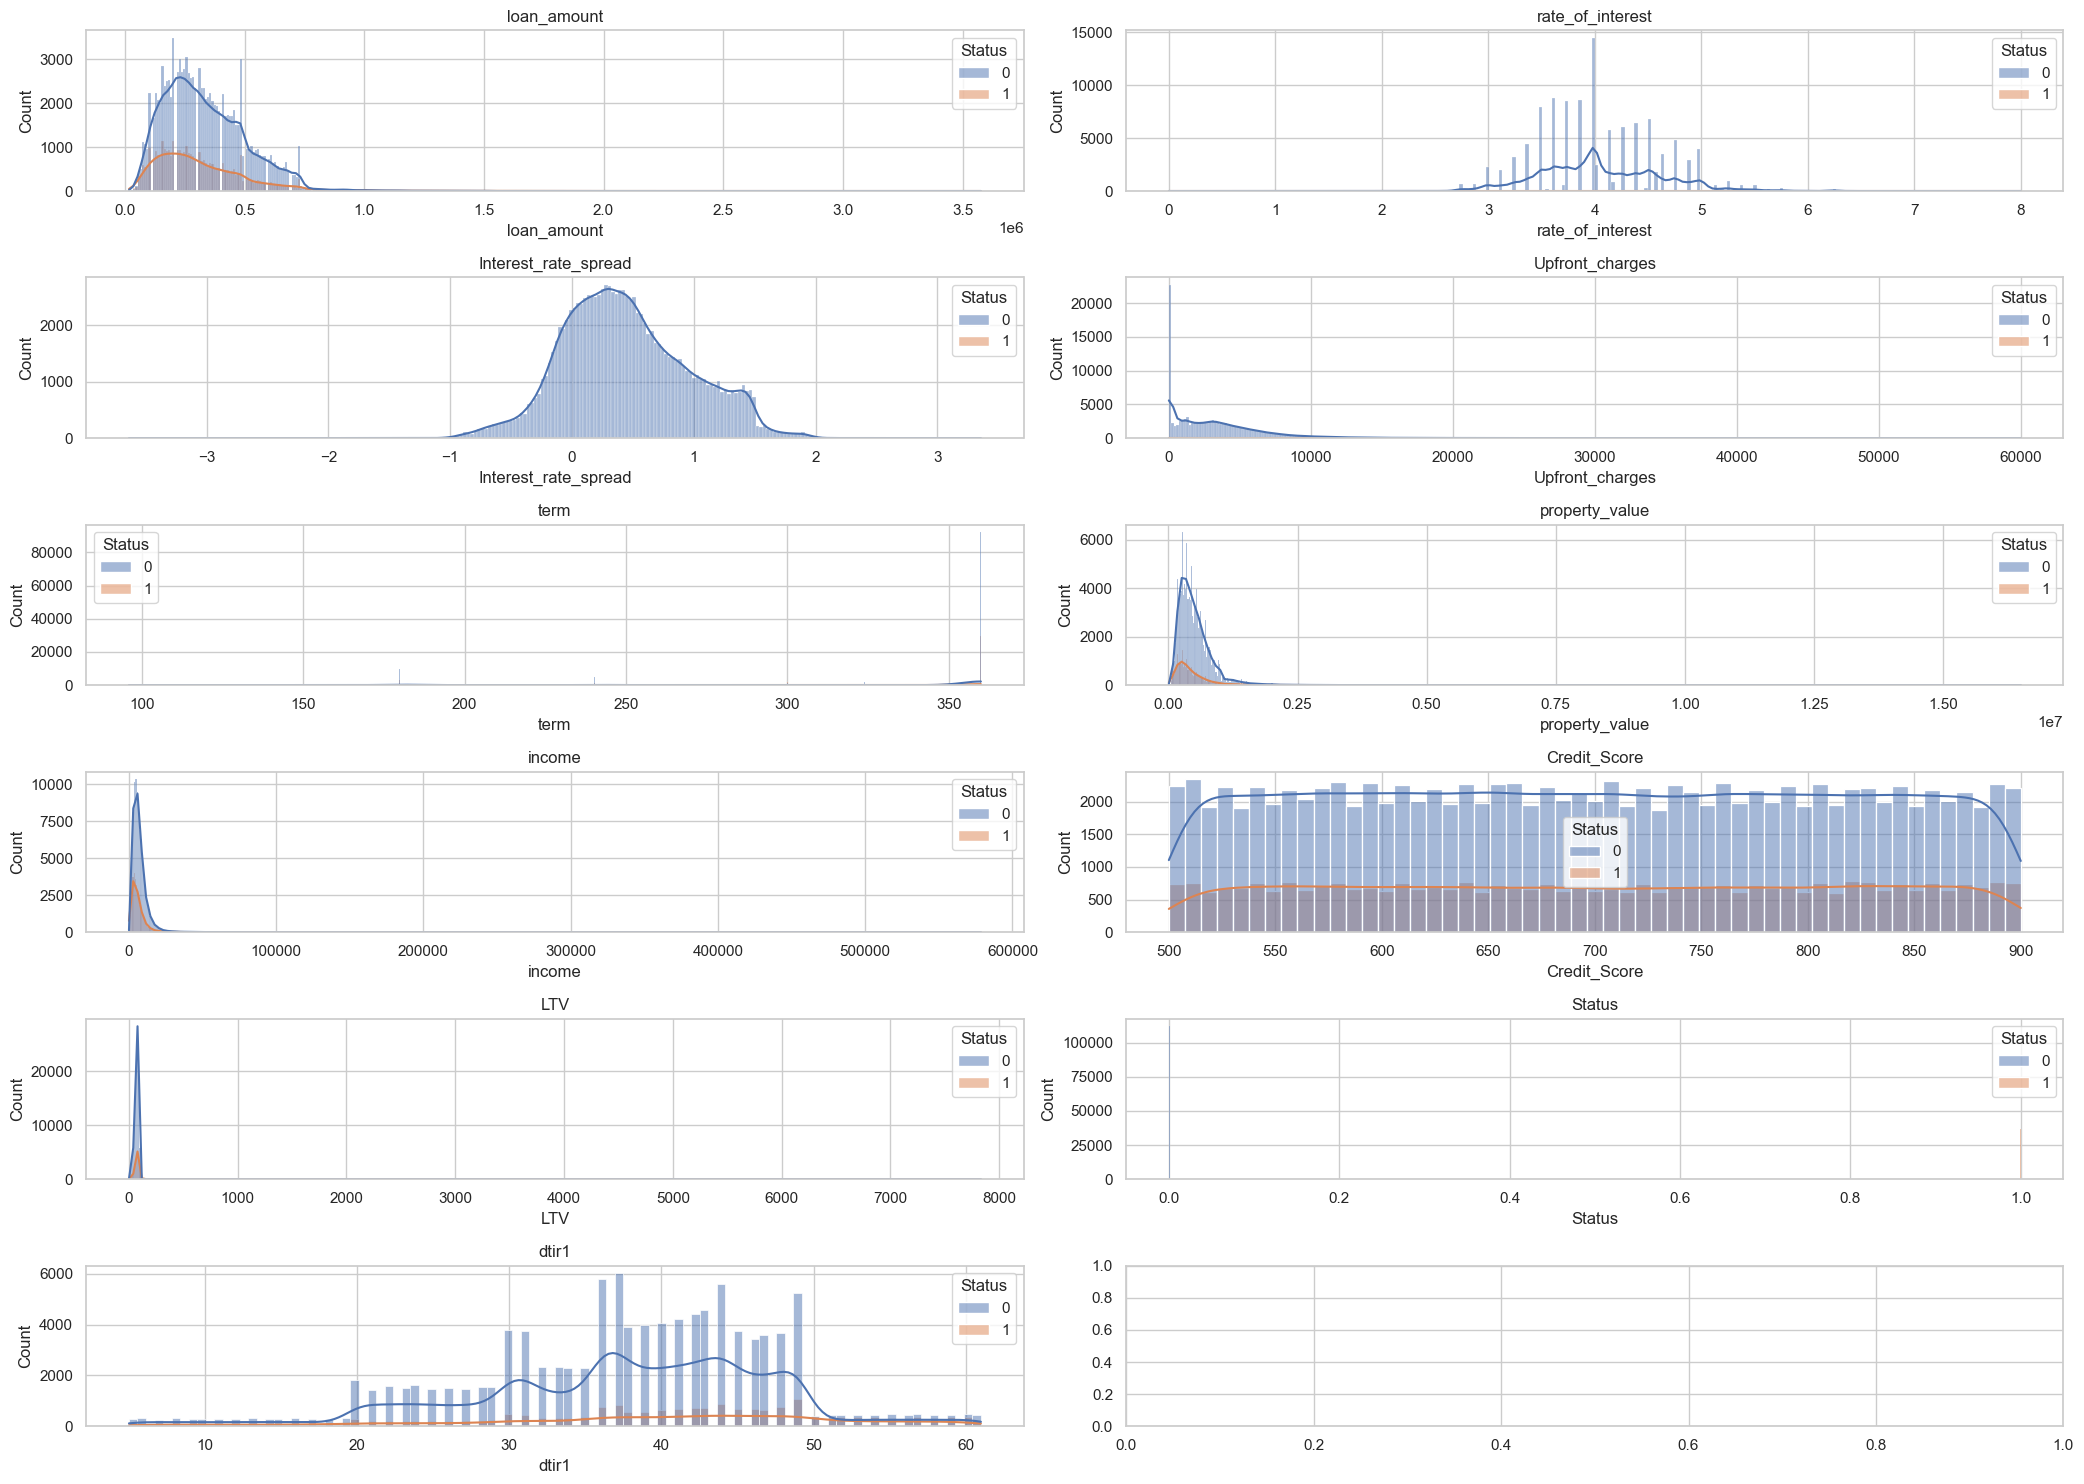

In [22]:
fig2,axes2 = plt.subplots(6,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(NumCols):
    sns.histplot(df,kde=True,x=col,ax=ax2[i],hue='Status').set_title(col)

plt.tight_layout()
plt.show()

In [14]:
log_cols = ['LTV','property_value','Upfront_charges','loan_amount','income']

In [24]:
logDF= np.log1p(df[log_cols])
logDF['Status'] = df['Status']

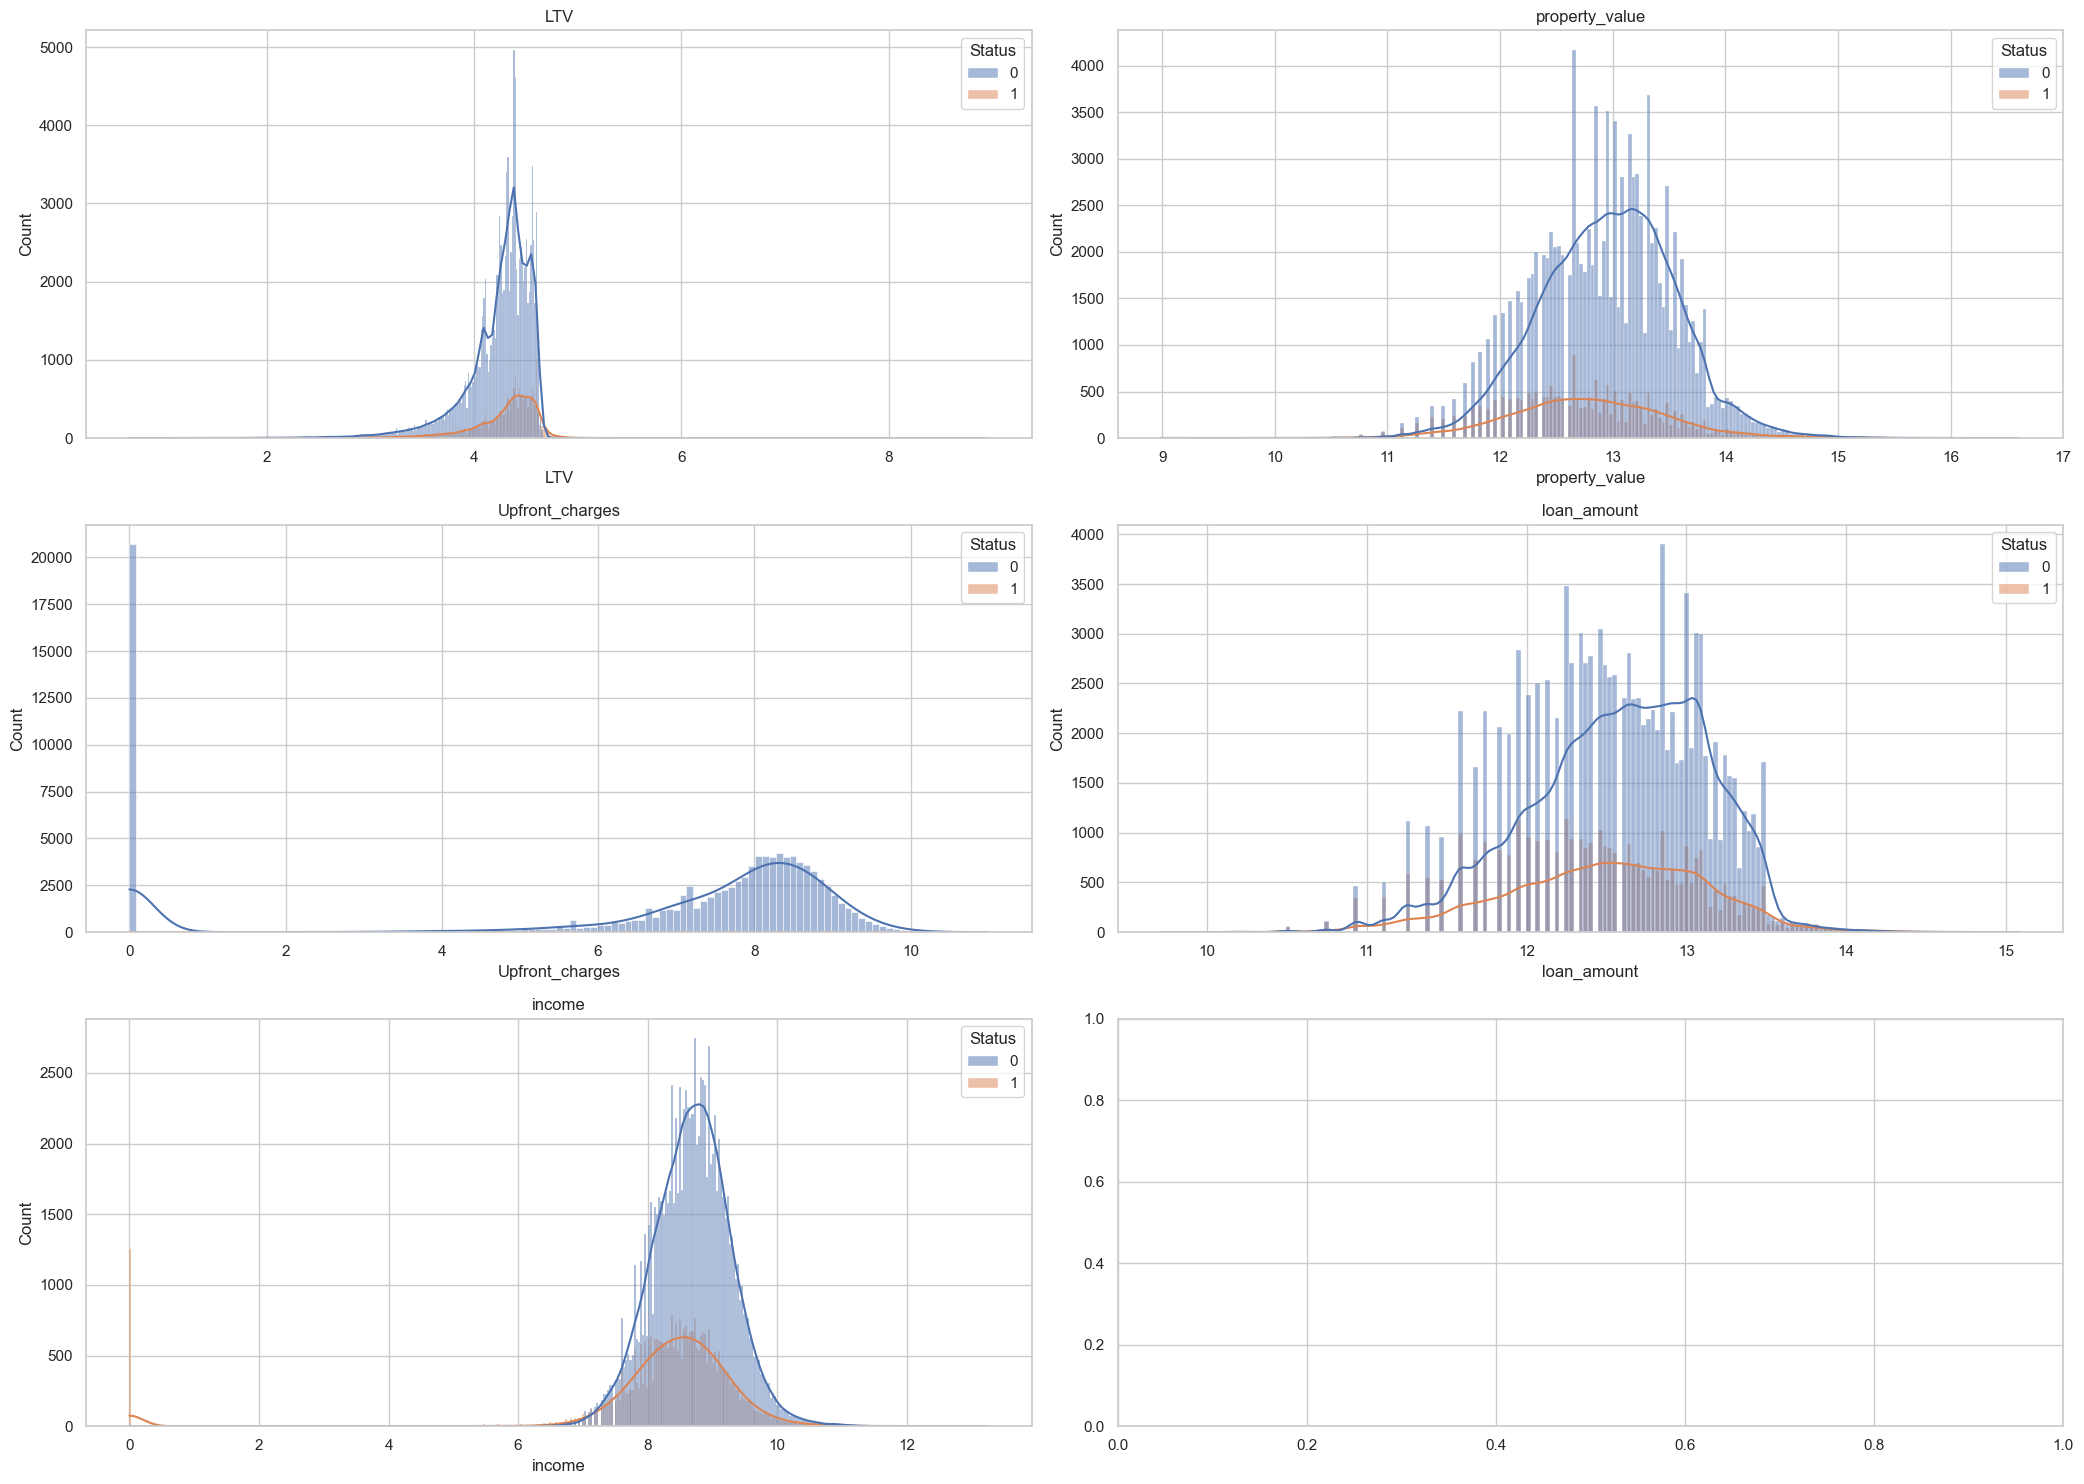

In [25]:
fig2,axes2 = plt.subplots(3,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(log_cols):
    sns.histplot(logDF,kde=True,x=col,ax=ax2[i],hue='Status').set_title(col)

plt.tight_layout()
plt.show()

In [26]:
df[NumCols].isnull().sum()

loan_amount                 0
rate_of_interest        36439
Interest_rate_spread    36639
Upfront_charges         39642
term                       41
property_value          15098
income                   9150
Credit_Score                0
LTV                     15098
Status                      0
dtir1                   24121
dtype: int64

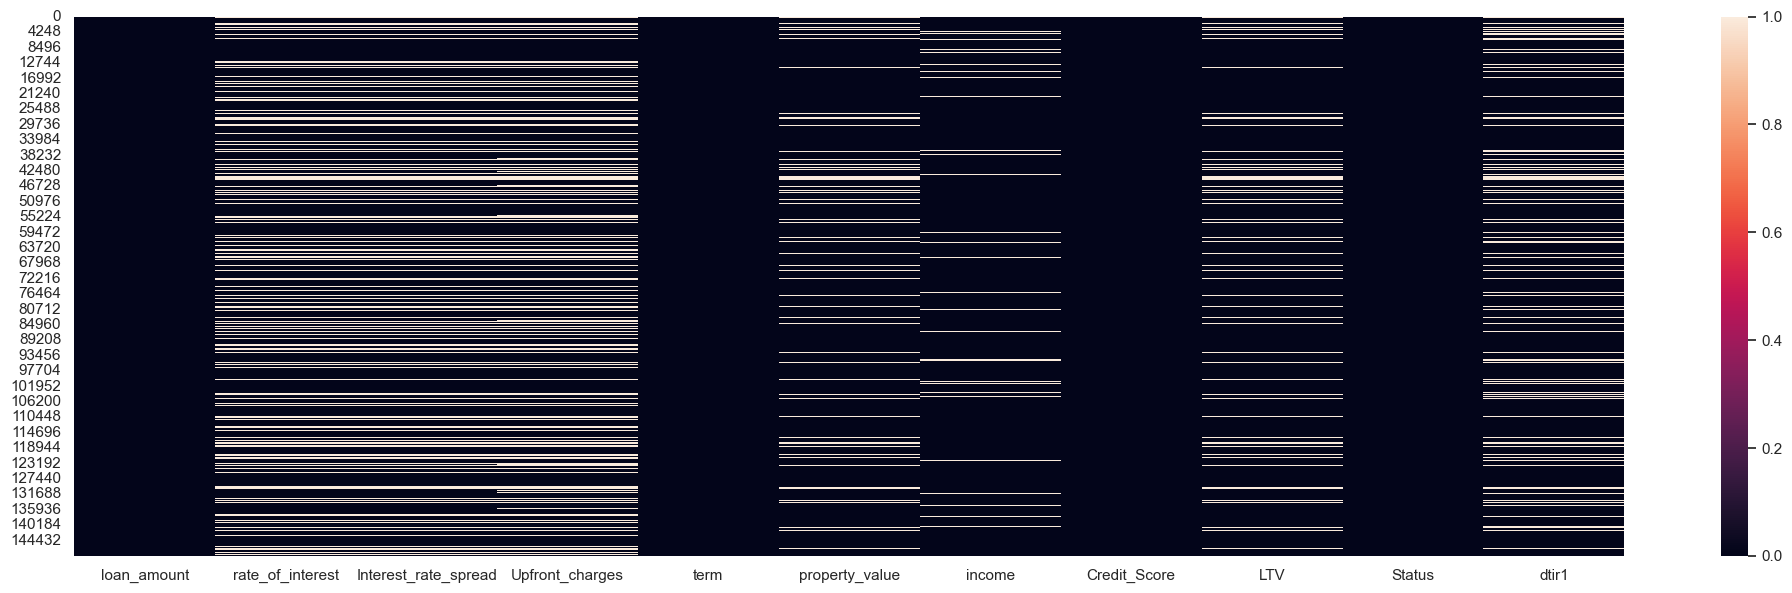

In [27]:
plt.figure(figsize=(25,7))
sns.heatmap(df[NumCols].isnull())
plt.show()

---

In [8]:
df

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.560,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.250,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.000,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.125,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.190,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.125,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.500,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


In [9]:
df[df['Status']==1].describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,3.663900e+04,200.000000,0.0,153.000000,36624.000000,2.154300e+04,35400.000000,36639.000000,21543.000000,36639.0,20329.000000
mean,3.192752e+05,4.350500,NaN,1565.237974,335.112085,4.577860e+05,6231.806780,700.600344,76.291468,1.0,39.597324
std,2.085768e+05,0.495546,NaN,2299.820513,57.120208,4.362550e+05,7247.649876,116.487189,28.580217,0.0,12.716828
min,1.650000e+04,3.125000,NaN,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,1.0,5.000000
25%,1.765000e+05,3.990000,NaN,0.000000,360.000000,2.280000e+05,3000.000000,599.500000,64.273172,1.0,32.000000
50%,2.765000e+05,4.312500,NaN,687.850000,360.000000,3.480000e+05,4860.000000,700.000000,79.362416,1.0,42.000000
75%,4.165000e+05,4.750000,NaN,2310.750000,360.000000,5.580000e+05,7620.000000,803.000000,90.948276,1.0,49.000000
max,3.576500e+06,5.500000,NaN,15584.000000,360.000000,1.650800e+07,578580.000000,900.000000,2956.250000,1.0,61.000000


In [10]:
df[df['Status']==0].describe()


,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,1.120310e+05,112031.000000,112031.000000,108875.000000,112005.000000,1.120290e+05,104120.000000,112031.000000,112029.000000,112031.0,104220.000000
mean,3.349908e+05,4.044931,0.441656,3227.328554,335.144592,5.056061e+05,7204.014214,699.523793,72.064757,0.0,37.369267
std,1.749166e+05,0.561356,0.513043,3251.673989,58.824650,3.427845e+05,6201.339600,115.674510,41.768899,0.0,10.027197
min,2.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,2.072943,0.0,5.000000
25%,2.065000e+05,3.625000,0.076000,584.390000,360.000000,2.880000e+05,4020.000000,599.000000,59.970817,0.0,31.000000
50%,3.065000e+05,3.990000,0.390400,2600.000000,360.000000,4.280000e+05,6000.000000,699.000000,74.504405,0.0,38.000000
75%,4.465000e+05,4.375000,0.775400,4815.315000,360.000000,6.380000e+05,8760.000000,800.000000,85.201149,0.0,44.000000
max,3.006500e+06,8.000000,3.357000,60000.000000,360.000000,9.268000e+06,377220.000000,900.000000,7831.250000,0.0,61.000000


In [11]:
newdf = pd.read_csv('data/Cleaned_loan_records.csv')

In [12]:
newdf

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,has_Upfront_charges
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,4.26145,...,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.000000,0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,4.02855,...,552,EXP,55-64,to_inst,0.677644,North,direct,1,19.864749,0
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56000,...,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.000000,1
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25000,...,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.000000,0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00000,...,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147752,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.12500,...,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.000000,1
147753,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.19000,...,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.000000,0
147754,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.12500,...,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.000000,1
147755,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.50000,...,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.000000,1


In [15]:
logDF= np.log1p(newdf[log_cols])
logDF['Status'] = newdf['Status']

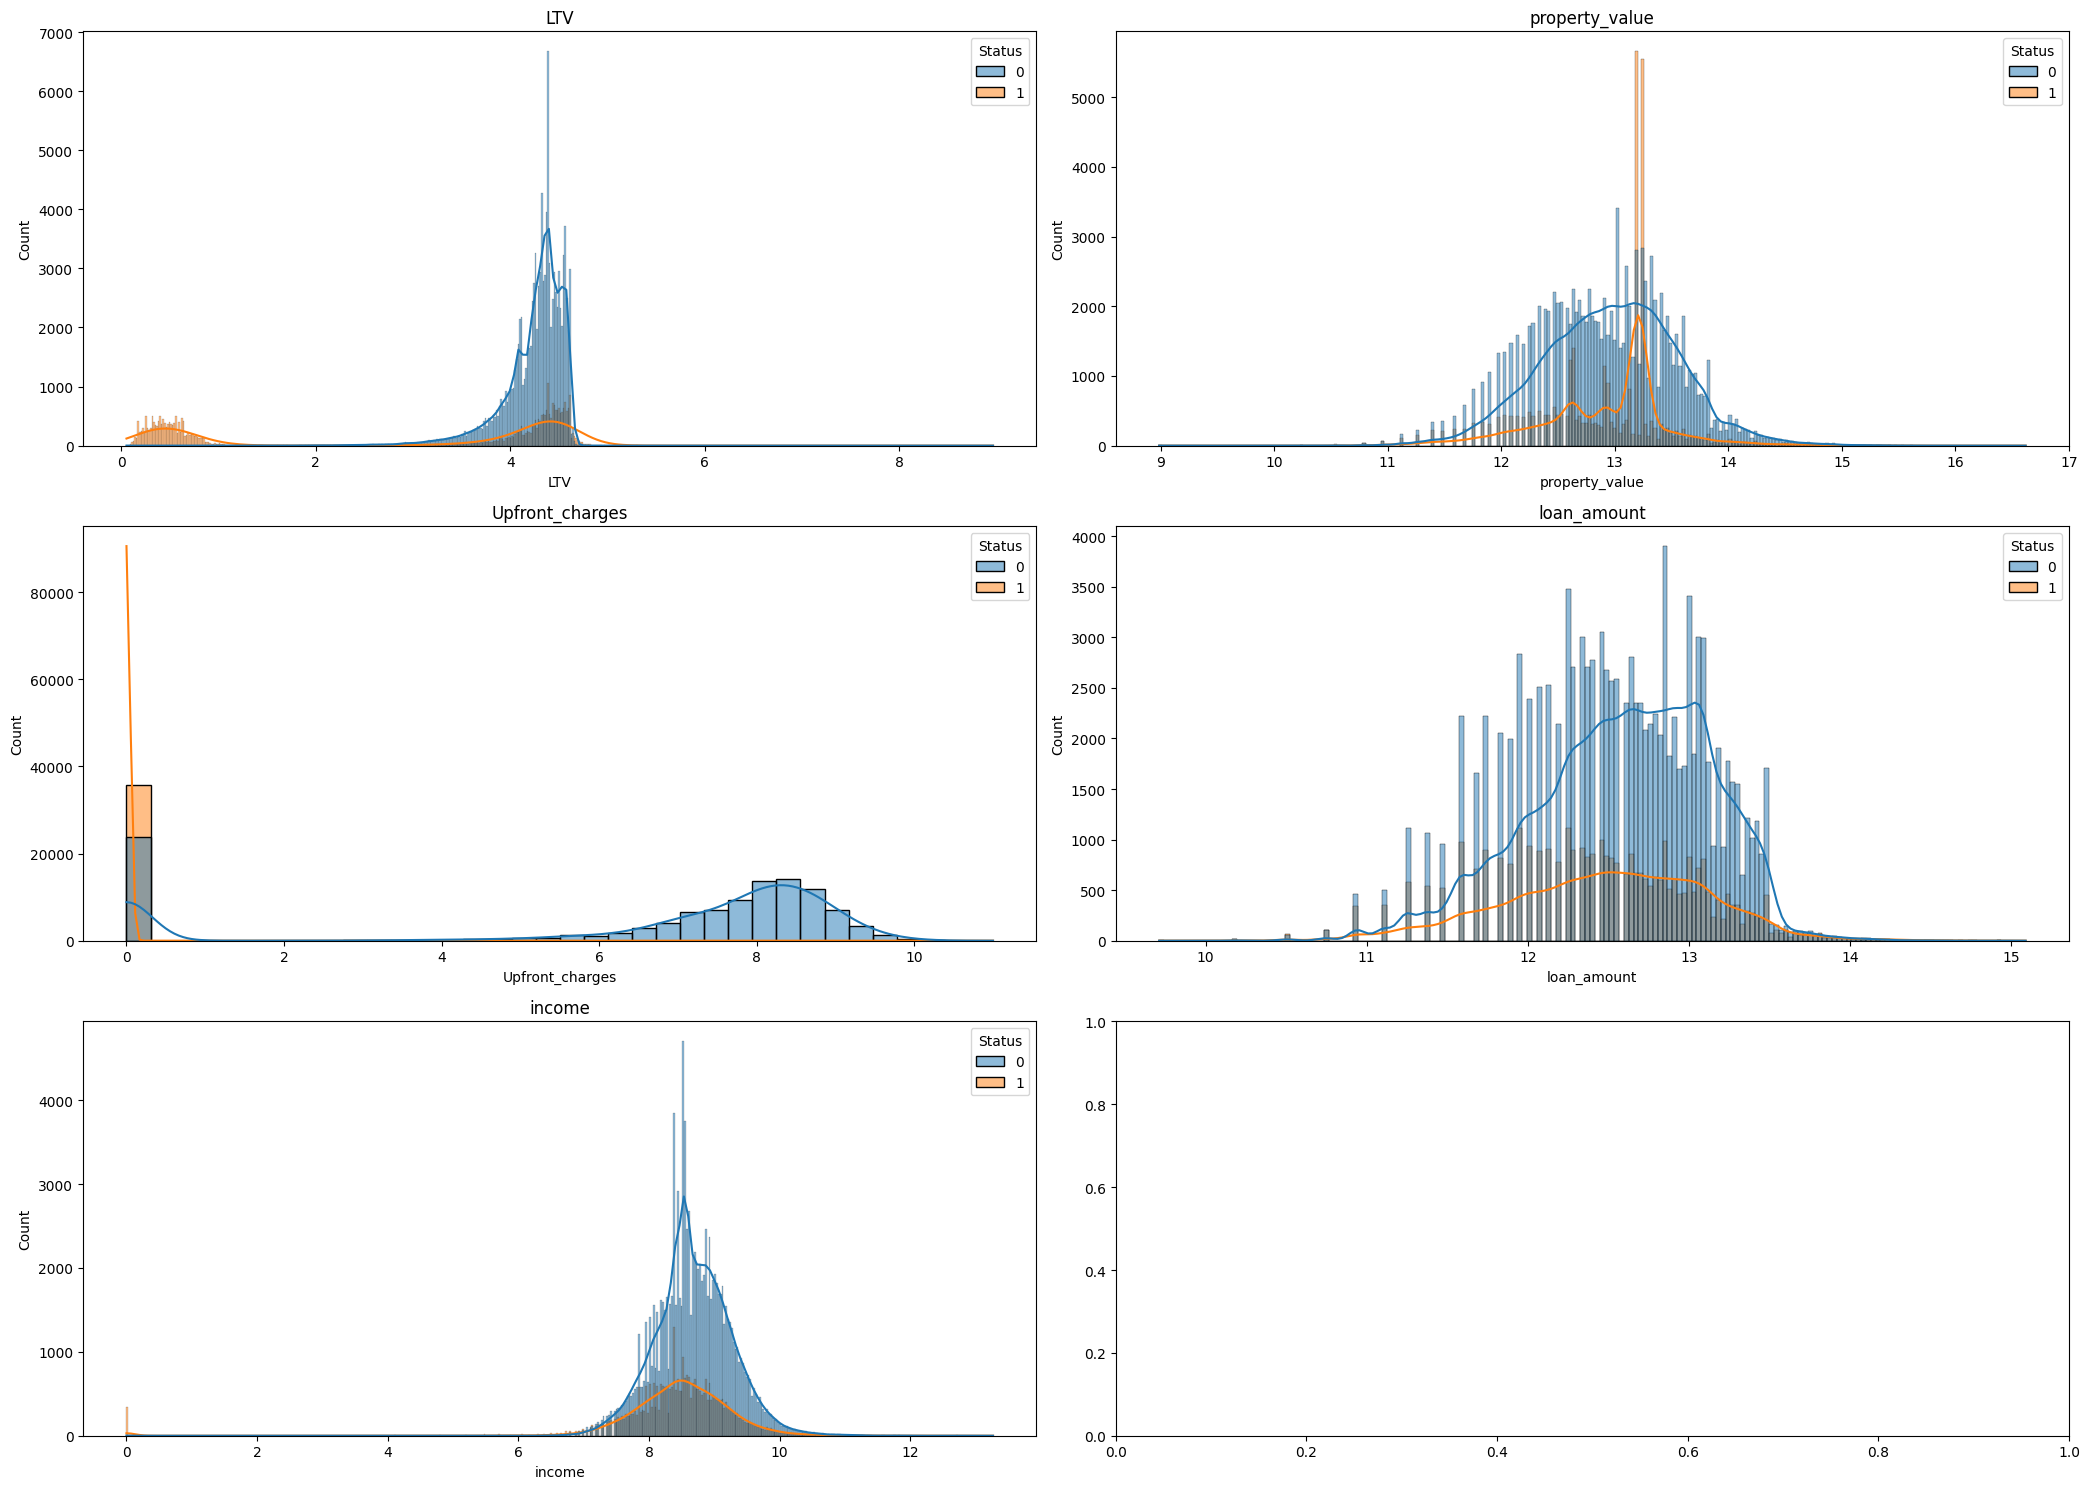

In [16]:
fig2,axes2 = plt.subplots(3,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(log_cols):
    sns.histplot(logDF,kde=True,x=col,ax=ax2[i],hue='Status').set_title(col)

plt.tight_layout()
plt.show()

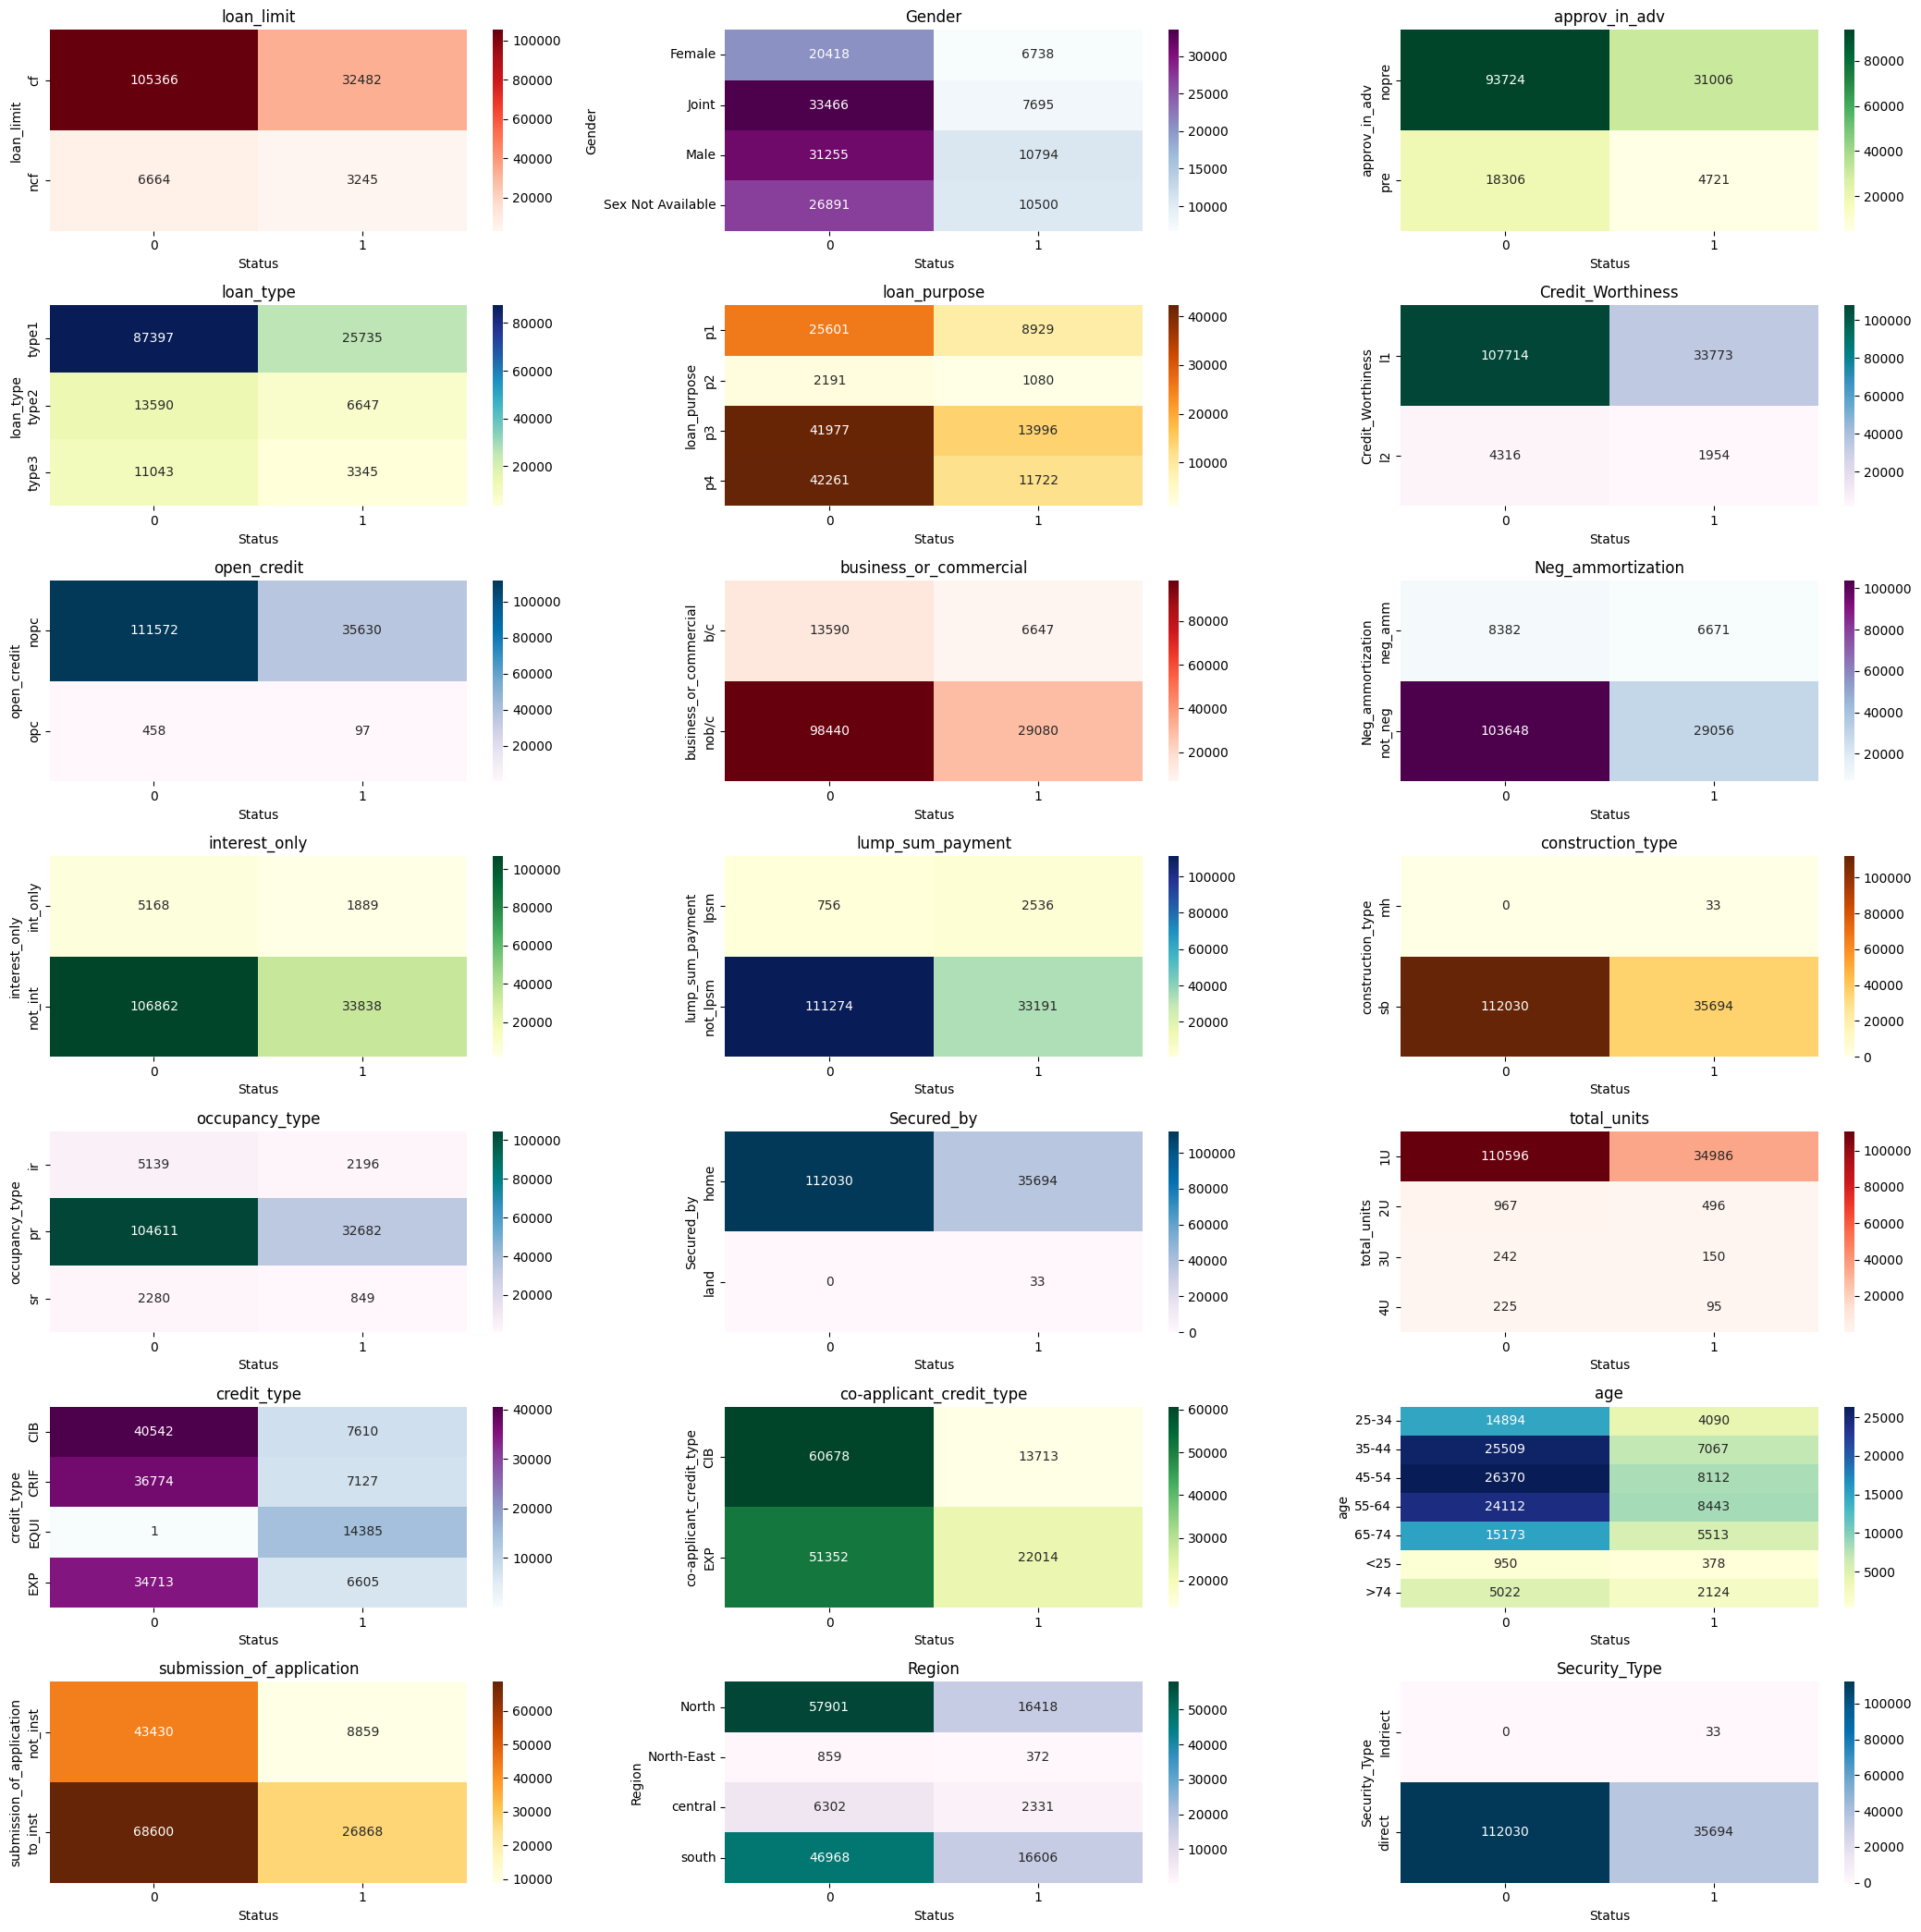

In [17]:
fig,axes = plt.subplots(7,3,figsize=(21,21))
ax = axes.flatten()
colors = ['Reds','BuPu','YlGn','YlGnBu','YlOrBr','PuBuGn','PuBu']
for i,col in enumerate(CatCols):
    sns.heatmap(pd.crosstab(columns=newdf['Status'],index=newdf[col]),annot=True,fmt="d",ax=ax[i],cmap=colors[i%7]).set_title(col)

plt.tight_layout()
plt.show()